In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('D:\\End to end ML projects\\House_Price_Prediction\\data\\raw\\Housing.csv')

In [3]:
df.shape

(545, 13)

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['price'].describe()

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

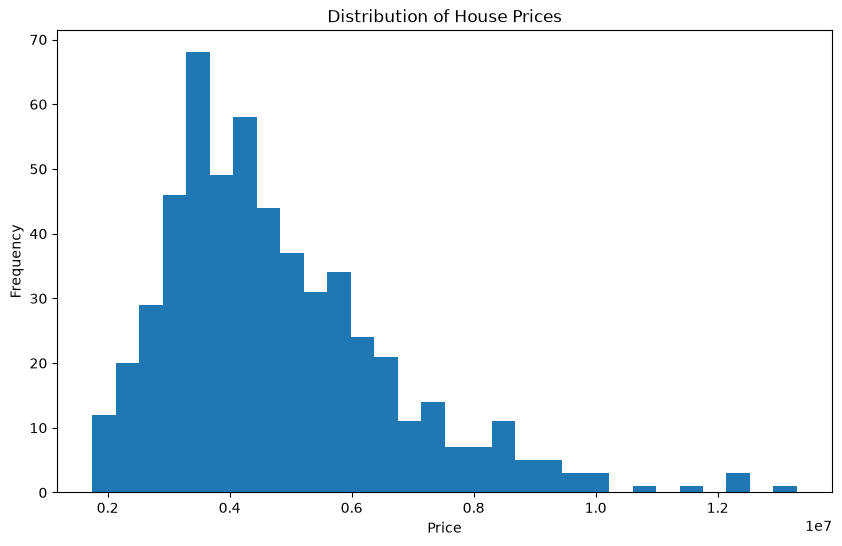

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=30)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')
plt.show() 

In [10]:
corr = df.corr(numeric_only=True)

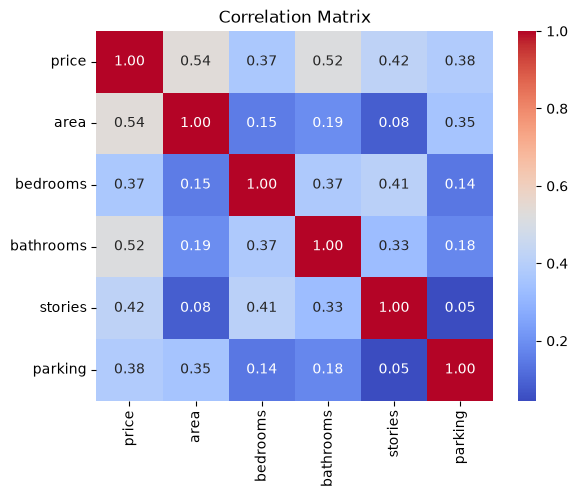

In [11]:
plt.Figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [12]:
corr['price'].sort_values(ascending=False)

price        1.000000
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

In [13]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]
print(len(outliers))

15


In [14]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(output_dir / "cleaned_housing.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [15]:
X = df.drop(columns=['price'])
y = df['price']

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [17]:
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

In [18]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [20]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [21]:
import pickle

In [22]:
from pathlib import Path

output_dir = Path("../artifacts")
output_dir.mkdir(parents=True, exist_ok=True)

with open(output_dir / "preprocessor.pkl", "wb") as file:
    pickle.dump(preprocessor, file)

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [29]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, objective="reg:squarederror")
}


In [31]:
result=[]

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [34]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    result.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

In [35]:
result

[{'Model': 'Linear Regression',
  'MAE': 920392.9397607954,
  'MSE': 1523019469501.2908,
  'RMSE': 1234106.7496376846,
  'R2 Score': 0.6463350878895878},
 {'Model': 'Decision Tree',
  'MAE': 1233876.768292683,
  'MSE': 3407670502476.2197,
  'RMSE': 1845987.6766859035,
  'R2 Score': 0.20869462742053613},
 {'Model': 'Random Forest',
  'MAE': 956488.7528455284,
  'MSE': 1820261875172.3833,
  'RMSE': 1349170.8102284097,
  'R2 Score': 0.5773115386951857},
 {'Model': 'Gradient Boosting',
  'MAE': 934428.6057100543,
  'MSE': 1612320467235.6501,
  'RMSE': 1269771.816995341,
  'R2 Score': 0.6255982357694794},
 {'Model': 'XGBoost',
  'MAE': 1003233.1875,
  'MSE': 2055767457792.0,
  'RMSE': 1433794.775339902,
  'R2 Score': 0.5226240754127502}]

In [36]:
result_df = pd.DataFrame(result)
result_df = result_df.sort_values(by='R2 Score', ascending=False)
result_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,9.203929e+05,1.523019e+12,1.234107e+06,0.646335
3,Gradient Boosting,9.344286e+05,1.612320e+12,1.269772e+06,0.625598
2,Random Forest,9.564888e+05,1.820262e+12,1.349171e+06,0.577312
4,XGBoost,1.003233e+06,2.055767e+12,1.433795e+06,0.522624
1,Decision Tree,1.233877e+06,3.407671e+12,1.845988e+06,0.208695


In [38]:
best_model = result_df.iloc[0]['Model']
print(f"The best model is: {best_model}")

The best model is: Linear Regression


In [39]:
pickle.dump(models[best_model], open(output_dir / "best_model.pkl", "wb"))

In [44]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    models[best_model],
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print(scores)
print("Average CV Score:", scores.mean())

[0.69284397 0.50338124 0.72457182 0.5834641  0.62605032]
Average CV Score: 0.6260622904644441


In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
param_grid = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

In [47]:
grid_search = GridSearchCV(
    estimator=models[best_model],
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'fit_intercept': [True, False], 'positive': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed durin

In [48]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'fit_intercept': False, 'positive': False}
Best CV Score: 0.6260622904644444


In [50]:
best_lr = grid_search.best_estimator_

Y_pred_best = best_lr.predict(X_test)

print("Best Model Predictions on Test Set:")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best Model Predictions on Test Set:
R2 Score: 0.5226240754127502
MAE: 1003233.1875
RMSE: 1433794.775339902


In [53]:
pickle.dump(best_lr, open(output_dir / "best_model_lr.pkl", "wb"))

In [54]:
pickle.dump(preprocessor, open(output_dir / "preprocessor.pkl", "wb"))

In [59]:
load_model = pickle.load(open(output_dir / "best_model_lr.pkl", "rb"))
load_preprocessor = pickle.load(open(output_dir / "preprocessor.pkl", "rb"))

In [65]:
new_house = {
    "area": 8450,
    "bedrooms": 3,
    "bathrooms": 2,
    "stories": 2,
    "mainroad": "yes",
    "guestroom": "no",
    "basement": "yes",
    "hotwaterheating": "no",
    "airconditioning": "yes",
    "parking": 2,
    "prefarea": "yes",
    "furnishingstatus": "semi-furnished"
}

In [66]:
new_house_df = pd.DataFrame([new_house])

In [67]:
new_house_processed = load_preprocessor.transform(new_house_df)

In [68]:
pridicted_price = load_model.predict(new_house_processed)

In [69]:
print(f"The predicted price for the new house is: ${pridicted_price[0]:,.2f}")

The predicted price for the new house is: $8,113,056.90
